In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.visualise import set_style
set_style()

# <center>$\beta$-profile</center>

$$n=n_0\bigg(1+\frac{r}{r_c}\bigg)^{-3\beta/2}$$

In [2]:
def beta_profile(r, n_0=1.,r_c=1., beta=1.):
    return n_0 * (1 + (r/r_c)**2)**(-3*beta/2)

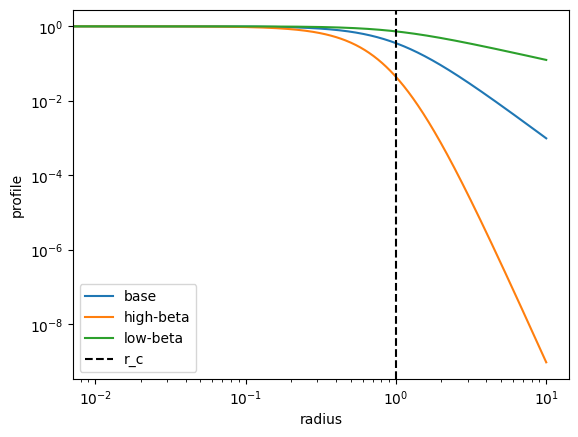

In [20]:
r = np.linspace(0,10,1000)

plt.plot(r,beta_profile(r),label='base')
plt.plot(r,beta_profile(r,beta=3.),label='high-beta')
plt.plot(r,beta_profile(r,beta=.3),label='low-beta')
plt.axvline(1,label='r_c',ls='--',color='k')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius')
plt.ylabel('profile')
plt.legend()
plt.show()

# <center>NFW Profile</center>

$$P=\frac{P_0}{(r/r_s)(1+r/r_s)^2}$$

In [3]:
def NFW_profile(r, p_0=1.,r_s=1.):
    return p_0 / (r/r_s) / (1+r/r_s)**2

/tmp/ipykernel_199980/1548033517.py:2: RuntimeWarning: divide by zero encountered in divide
  return n_0 / (r/r_s) / (1+r/r_s)**2


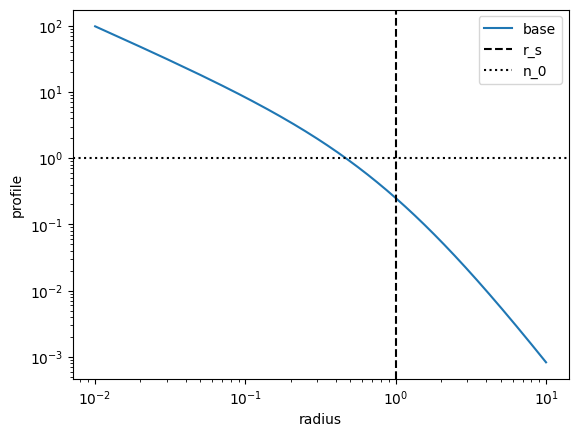

In [21]:
r = np.linspace(0,10,1000)

plt.plot(r,NFW_profile(r),label='base')
plt.axvline(1,label='r_s',ls='--',color='k')
plt.axhline(1,label='n_0',ls=':',color='k')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius')
plt.ylabel('profile')
plt.legend()
plt.show()

# <center>gNFW Profile</center>

$$P=\frac{P_0}{(c_{500}r/r_s)^\gamma(1+c_{500}r/r_s)^{(\beta-\gamma)/\alpha}},\hspace{5mm}r_s=r_{500}/c_{500}$$

In [4]:
def gNFW_profile(r, p_0=1.,r_500=1.,c_500=1.,alpha=1.,beta=3.,gamma=1.):
    r_s = r_500/c_500
    x = r/r_s
    return p_0 / (c_500*x)**gamma / (1+(c_500*x)**alpha)**((beta-gamma)/alpha)

/tmp/ipykernel_199980/3176203268.py:2: RuntimeWarning: divide by zero encountered in divide
  return p_0 / (r/r_s) / (1+r/r_s)**2
/tmp/ipykernel_199980/3965500001.py:4: RuntimeWarning: divide by zero encountered in divide
  return p_0 / (c_500*x)**gamma / (1+(c_500*x)**alpha)**((beta-gamma)/alpha)


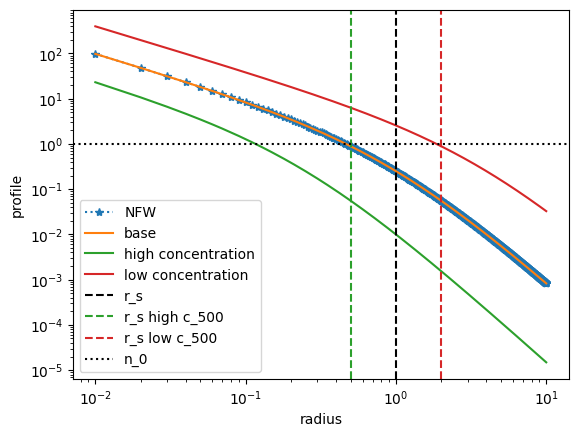

In [36]:
r = np.linspace(0,10,1000)

plt.plot(r,NFW_profile(r),label='NFW',ls=':',marker='*')
plt.plot(r,gNFW_profile(r),label='base')
plt.plot(r,gNFW_profile(r,c_500=2.),label='high concentration')
plt.plot(r,gNFW_profile(r,c_500=.5),label='low concentration')
plt.axvline(1,label='r_s',ls='--',color='k')
plt.axvline(1/2.,label='r_s high c_500',ls='--',color='tab:green',)
plt.axvline(1/.5,label='r_s low c_500',ls='--',color='tab:red',)
plt.axhline(1,label='n_0',ls=':',color='k')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius')
plt.ylabel('profile')
plt.legend()
plt.show()

# <center>Einasto Profile</center>

$$n=n_{-2}\exp\bigg(-\frac{2}{\alpha}\bigg[\bigg(\frac{r}{r_{-2}}\bigg)^\alpha-1\bigg]\bigg)$$

In [5]:
def einasto_profile(r, n_2=1., r_2=1., alpha=1.):
    return n_2 * np.exp(-2/alpha * ((r/r_2)**alpha-1))

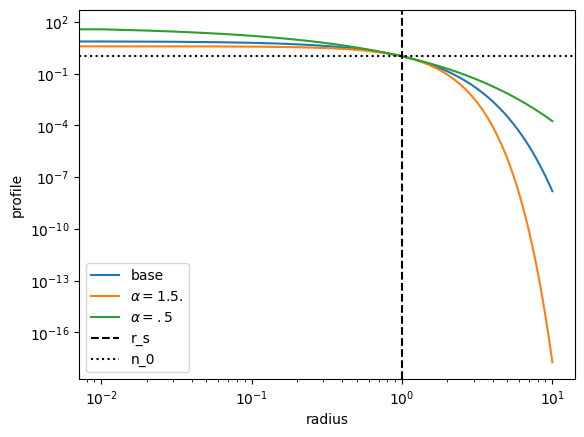

In [22]:
r = np.linspace(0,10,1000)

plt.plot(r,einasto_profile(r),label='base')
plt.plot(r,einasto_profile(r,alpha=1.5),label=r'$\alpha=1.5.$')
plt.plot(r,einasto_profile(r,alpha=.5),label=r'$\alpha=.5$')
plt.axvline(1,label='r_s',ls='--',color='k')
plt.axhline(1,label='n_0',ls=':',color='k')
plt.yscale('log')
plt.xscale('log')
plt.xlabel('radius')
plt.ylabel('profile')
plt.legend()
plt.show()

# Plot all profiles together

In [27]:
r = np.logspace(-2,1,1000)

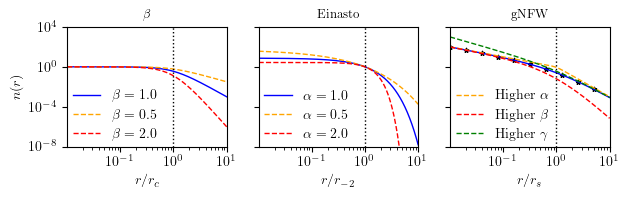

In [40]:
fig, axes = plt.subplots(1,3,figsize=(7,4),sharey=True)

axes[0].set_title(r'$\beta$')
axes[0].set_xlabel(r'$r/r_c$')
axes[0].plot(r,beta_profile(r,n_0=1.,r_c=1.,beta=1.),marker='',label=r'$\beta=1.0$')
axes[0].plot(r,beta_profile(r,n_0=1.,r_c=1.,beta=.5),marker='',ls='--',label=r'$\beta=0.5$')
axes[0].plot(r,beta_profile(r,n_0=1.,r_c=1.,beta=2.),marker='',ls='--',label=r'$\beta=2.0$')

axes[1].set_title('Einasto')
axes[1].set_xlabel(r'$r/r_{-2}$')
axes[1].plot(r,einasto_profile(r,n_2=1.,r_2=1.,alpha=1.),marker='',label=r'$\alpha=1.0$')
axes[1].plot(r,einasto_profile(r,n_2=1.,r_2=1.,alpha=.5),marker='',ls='--',label=r'$\alpha=0.5$')
axes[1].plot(r,einasto_profile(r,n_2=1.,r_2=1.,alpha=2.),marker='',ls='--',label=r'$\alpha=2.0$')

axes[2].set_title('gNFW')
axes[2].set_xlabel(r'$r/r_s$')
# axes[2].plot(r,NFW_profile(r,p_0=1.,r_s=1.),marker='')
axes[2].plot(r,gNFW_profile(r, p_0=1.,r_500=1.,c_500=1.,alpha=1.,beta=3.,gamma=1.),marker='')
axes[2].plot(r,gNFW_profile(r, p_0=1.,r_500=1.,c_500=1.,alpha=10.,beta=3.,gamma=1.),marker='',ls='--',label=r'Higher $\alpha$')
axes[2].plot(r,gNFW_profile(r, p_0=1.,r_500=1.,c_500=1.,alpha=1.,beta=5.,gamma=1.),marker='',ls='--',label=r'Higher $\beta$')
axes[2].plot(r,gNFW_profile(r, p_0=1.,r_500=1.,c_500=1.,alpha=1.,beta=3.,gamma=1.5),marker='',ls='--',label=r'Higher $\gamma$')
axes[2].scatter(r[::100],gNFW_profile(r[::100], p_0=1.,r_500=1.,c_500=1.,alpha=1.,beta=3.,gamma=1.),marker='*',s=10,color='k')

for i,ax in enumerate(axes):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(r[0],r[-1])
    ax.set_ylim(1e-8,1e3)
    ax.set_xticks([1e-1,1,1e1])
    ax.set_yticks([1e-8,1e-4,1,1e4])
    ax.legend(frameon=False,loc=(.00,.00))
    
    ax.axvline(1,color='k',ls=':')
    
    ax.set_box_aspect(.75)
    if i==0:
        ax.set_ylabel(r'$n(r)$')
    
    # ax.legend(loc='lower left')

fig.savefig('/home/yange/Documents/VUW/First Year Proposal/images/profiles.png',dpi=300,facecolor='w',bbox_inches='tight')
plt.show()